# OD Analysis

This notebook investigates the effect of bead treatment on optical density (OD) across three experiment types: `96-well`, `24-well`, and `ttubes`. It loads curated OD measurements, computes per-condition summary statistics, and visualizes afternoon-timepoint comparisons against matched no-bead controls.

The goal is to assess whether adding beads shifts OD within each experimental setup, with statistical comparisons made explicit in the figures.

In [1]:
from pathlib import Path

import arcadia_pycolor as apc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

apc.mpl.setup()

## Data preparation

The measurements are loaded from `data/plate-reader/od-measurements.csv`, where each row is a single replicate. The sample shown below is a quick sanity check that the data were read correctly and that the expected experimental variables are available for filtering and grouping.

In [2]:
REPO_ROOT = Path().resolve().parent

csv_path = REPO_ROOT / "data" / "plate-reader" / "od-measurements.csv"
df = pd.read_csv(csv_path)
df.sample(5, random_state=42)

,experiment,strain,volume,time,beads,rep,OD,supplement
33,24-well,SP286,3,morning,4.5,1,1.59,none
6,24-well,SP286,1,morning,0.0,1,1.44,none
182,ttubes,SP286,4,morning,0.0,1,0.82,none
86,96-well,SP286,1,afternoon,0.0,3,0.42,none
156,ttubes,SP286,2,afternoon,4.5,2,10.49,none


## Statistical setup

The two helper functions below handle p-value correction and figure annotation. Raw p-values from Welch's t-tests are adjusted using Holm-Bonferroni correction and converted to star notation (`*` p < 0.05, `**` p < 0.01, `***` p < 0.001) placed above the relevant bars in each figure.

In [3]:
def pval_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""


def correct_pvalues(pvals):
    """Apply Holm-Bonferroni correction, tolerating NaNs."""
    valid_mask = [not np.isnan(p) for p in pvals]
    if not any(valid_mask):
        return list(pvals)
    valid_pvals = [p for p, v in zip(pvals, valid_mask, strict=True) if v]
    _, corrected, _, _ = multipletests(valid_pvals, method="holm")
    corrected_iter = iter(corrected)
    return [next(corrected_iter) if v else np.nan for v in valid_mask]

## 96-well plate — Afternoon

Each bar shows mean OD across replicates for a given bead size; error bars are approximate 95% confidence intervals (1.96 × SEM). Significance stars mark bead sizes whose OD differs from the no-bead control after Holm-Bonferroni correction.

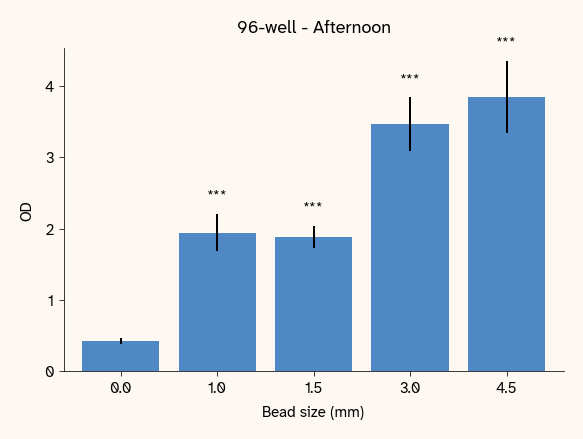

In [4]:
df_96_afternoon = df[(df["experiment"] == "96-well") & (df["time"].str.lower() == "afternoon")]
bead_values = sorted(df_96_afternoon["beads"].unique())
means = df_96_afternoon.groupby("beads")["OD"].mean()
stds = df_96_afternoon.groupby("beads")["OD"].std()
counts = df_96_afternoon.groupby("beads")["OD"].count()
cis = 1.96 * stds / np.sqrt(counts)

x = np.arange(len(means))
fig, ax = plt.subplots(figsize=(8, 6), facecolor=apc.parchment)
ax.bar(x, means, yerr=cis, capsize=6)
ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in means.index])
ax.set_xlabel("Bead size (mm)")
ax.set_ylabel("OD")
ax.set_title("96-well - Afternoon")

# Welch's t-test vs control (beads=0), Holm-Bonferroni correction
control_od = df_96_afternoon[df_96_afternoon["beads"] == 0.0]["OD"].values
treatment_beads = [b for b in bead_values if b != 0.0]
raw_pvals = []
for b in treatment_beads:
    treat_od = df_96_afternoon[df_96_afternoon["beads"] == b]["OD"].values
    if len(control_od) > 1 and len(treat_od) > 1:
        _, p = ttest_ind(control_od, treat_od, equal_var=False)
    else:
        p = np.nan
    raw_pvals.append(p)

adj_pvals = correct_pvalues(raw_pvals)
y_offset = means.max() * 0.05
for b, adj_p in zip(treatment_beads, adj_pvals, strict=True):
    stars = pval_to_stars(adj_p)
    if stars:
        bar_idx = list(means.index).index(b)
        ax.text(bar_idx, means[b] + cis[b] + y_offset, stars, ha="center", va="bottom", fontsize=14)

apc.mpl.style_plot(ax)
plt.tight_layout()
svg_out = REPO_ROOT / "figures" / "od_bar_96-well.svg"
fig.savefig(svg_out, bbox_inches="tight", facecolor=apc.parchment)

## Volume-stratified comparisons — 24-well and ttubes

The `24-well` and `ttubes` datasets include a volume dimension, so each bead treatment is compared against its matched no-bead control within each volume level rather than pooled across volumes. Bar heights and error bars follow the same convention as above (mean ± 1.96 × SEM); significance stars reflect Holm-Bonferroni-corrected Welch's t-tests across all volume–bead pairs within each dataset.

In [5]:
def plot_volume_bead_bars(df_sub, title, save_path=None):
    """Grouped bar chart of OD by volume and bead size with significance annotations."""
    volumes = sorted(df_sub["volume"].unique())
    beads = sorted(df_sub["beads"].unique())

    means = df_sub.groupby(["volume", "beads"])["OD"].mean().unstack()
    counts = df_sub.groupby(["volume", "beads"])["OD"].count().unstack()
    stds = df_sub.groupby(["volume", "beads"])["OD"].std().unstack()
    cis = 1.96 * stds / np.sqrt(counts)

    x = np.arange(len(volumes))
    bar_w = 0.8 / len(beads)

    fig, ax = plt.subplots(figsize=(10, 6), facecolor=apc.parchment)
    for i, bead in enumerate(beads):
        ax.bar(
            x + (i - (len(beads) - 1) / 2) * bar_w,
            means[bead],
            width=bar_w,
            label=f"{bead}",
            yerr=cis[bead],
            capsize=6,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(volumes)
    ax.set_xlabel("Volume (mL)")
    ax.set_ylabel("OD")
    ax.set_title(title)
    ax.legend(title="Beads (mg/mL)", bbox_to_anchor=(1.05, 1), loc="upper left")

    # Welch's t-test per volume: beads=0 vs each treatment, Holm-Bonferroni correction
    treatment_beads = [b for b in beads if b != 0.0]
    comparisons, raw_pvals = [], []
    for v in volumes:
        control_od = df_sub[(df_sub["volume"] == v) & (df_sub["beads"] == 0.0)]["OD"].values
        for b in treatment_beads:
            treat_od = df_sub[(df_sub["volume"] == v) & (df_sub["beads"] == b)]["OD"].values
            if len(control_od) > 1 and len(treat_od) > 1:
                _, p = ttest_ind(control_od, treat_od, equal_var=False)
            else:
                p = np.nan
            comparisons.append((v, b))
            raw_pvals.append(p)

    adj_pvals = correct_pvalues(raw_pvals)
    y_offset = means.max().max() * 0.03
    for (v, b), adj_p in zip(comparisons, adj_pvals, strict=True):
        stars = pval_to_stars(adj_p)
        if stars:
            vi = volumes.index(v)
            ctrl_pos = x[vi] + (beads.index(0.0) - (len(beads) - 1) / 2) * bar_w
            treat_pos = x[vi] + (beads.index(b) - (len(beads) - 1) / 2) * bar_w
            y_max = max(means.loc[v, 0.0] + cis.loc[v, 0.0], means.loc[v, b] + cis.loc[v, b])
            ax.text(
                (ctrl_pos + treat_pos) / 2,
                y_max + y_offset,
                stars,
                ha="center",
                va="bottom",
                fontsize=14,
            )

    apc.mpl.style_plot(ax)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", facecolor=apc.parchment)
    plt.show()

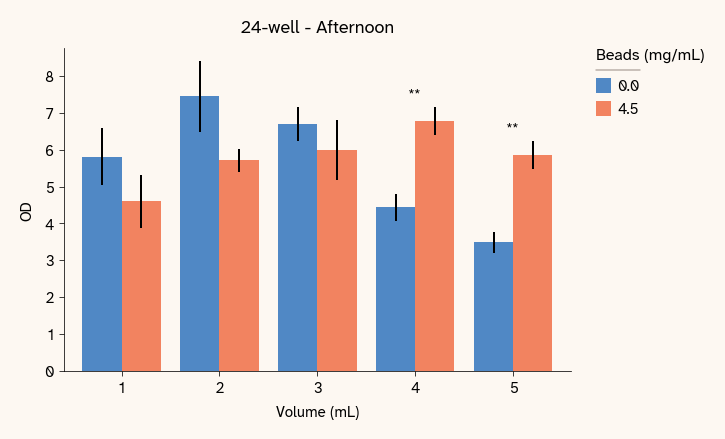

In [6]:
df_24 = df[(df["experiment"] == "24-well") & (df["time"].str.lower() == "afternoon")]
svg_out = REPO_ROOT / "figures" / "od_bar_24-well.svg"
plot_volume_bead_bars(df_24, "24-well - Afternoon", save_path=svg_out)

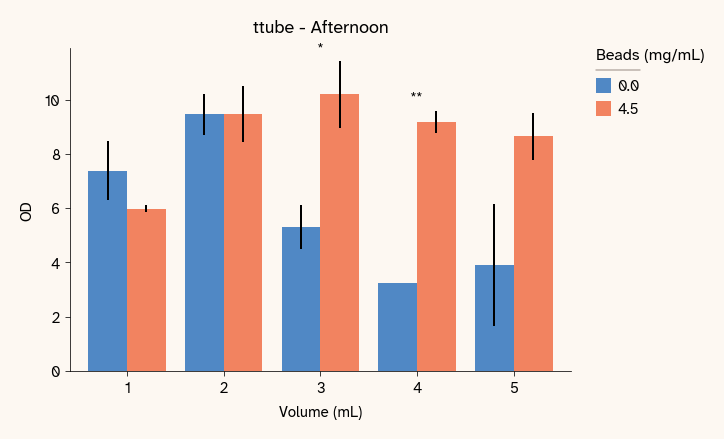

In [7]:
df_tt = df[(df["experiment"].str.lower() == "ttubes") & (df["time"].str.lower() == "afternoon")]
svg_out = REPO_ROOT / "figures" / "od_bar_ttubes.svg"
plot_volume_bead_bars(df_tt, "ttube - Afternoon", save_path=svg_out)

## Supplement experiment — Afternoon

The supplement experiment tests combinations of three additives against an unsupplemented control, all with 4.5 mm beads in 5 mL volume. Supplement abbreviations: **D** = dextrose 3%, **V** = vitamins, **A** = amino acids. Each bar shows mean OD across replicates; error bars are 95% confidence intervals (1.96 × SEM). Significance stars mark supplements whose OD differs from the no-supplement control after Holm-Bonferroni correction.

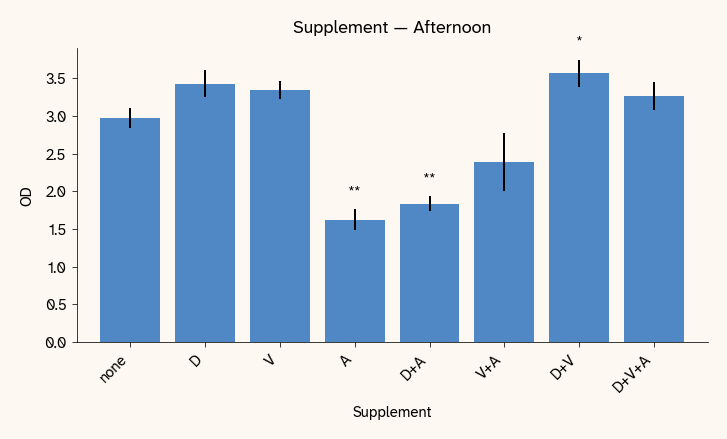

In [8]:
SUPP_ORDER = ["none", "D", "V", "A", "D+A", "V+A", "D+V", "D+V+A"]

df_supp_afternoon = df[(df["experiment"] == "supp") & (df["time"].str.lower() == "afternoon")]

means = df_supp_afternoon.groupby("supplement")["OD"].mean().reindex(SUPP_ORDER)
stds = df_supp_afternoon.groupby("supplement")["OD"].std().reindex(SUPP_ORDER)
counts = df_supp_afternoon.groupby("supplement")["OD"].count().reindex(SUPP_ORDER)
cis = 1.96 * stds / np.sqrt(counts)

x = np.arange(len(SUPP_ORDER))
fig, ax = plt.subplots(figsize=(10, 6), facecolor=apc.parchment)
ax.bar(x, means, yerr=cis, capsize=6)
ax.set_xticks(x)
ax.set_xticklabels(SUPP_ORDER, rotation=45, ha="right")
ax.set_xlabel("Supplement")
ax.set_ylabel("OD")
ax.set_title("Supplement — Afternoon")

control_od = df_supp_afternoon[df_supp_afternoon["supplement"] == "none"]["OD"].values
treatment_supps = [s for s in SUPP_ORDER if s != "none"]
raw_pvals = []
for s in treatment_supps:
    treat_od = df_supp_afternoon[df_supp_afternoon["supplement"] == s]["OD"].values
    if len(control_od) > 1 and len(treat_od) > 1:
        _, p = ttest_ind(control_od, treat_od, equal_var=False)
    else:
        p = np.nan
    raw_pvals.append(p)

adj_pvals = correct_pvalues(raw_pvals)
y_offset = means.max() * 0.05
for s, adj_p in zip(treatment_supps, adj_pvals, strict=True):
    stars = pval_to_stars(adj_p)
    if stars:
        bar_idx = SUPP_ORDER.index(s)
        ax.text(
            bar_idx, means[s] + cis[s] + y_offset, stars,
            ha="center", va="bottom", fontsize=14,
        )

apc.mpl.style_plot(ax)
plt.tight_layout()
svg_out = REPO_ROOT / "figures" / "od_bar_supp.svg"
fig.savefig(svg_out, bbox_inches="tight", facecolor=apc.parchment)